In [ ]:
import pandas as pd
import numpy as np
import sys 
import os 

from sklearn import set_config
from sklearn.model_selection import train_test_split
from sksurv.linear_model import CoxnetSurvivalAnalysis
set_config(display="text")  # displays text representation of estimators

from sksurv.util import Surv
sys.path.append(os.path.abspath("../../"))
from src.utils.ConvertTextToCsv import TextToCsv
from src.utils.Preprocessing import Preprocessor
from src.utils.plots import Plots
%load_ext autoreload
%autoreload 2
%matplotlib inline


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
pp = Preprocessor()
plots_class = Plots()

In [9]:
df_clinical_data = pd.read_csv("../../data/raw/brca_tcga_pub2015_clinical_data.tsv", sep='\t')
df_clinical_data = pp.clean_columns_dataset(df_clinical_data)
list_df = pp.total_type_len_type_cancer(df_clinical_data)
df_clinical_data["Tumor-Cancer"] = list_df
df_clinical_data["Tumor-Cancer"].unique()

df_mRNA_raw_data = TextToCsv("../../data/raw/data_mrna_seq_v2_rsem.txt")


Luminal A: 330 - Total(%): 0.40
Luminal B: 81 - Total(%):0.10
HER2-enriched: 23 - Total(%):0.03
TNBC: 85 - Total(%)0.10 
UNK: 299 - Total(%) 0.37
Shape of the CSV: (20440, 819)


In [10]:
clean_mRNA_df = pp.eliminate_zero_genes(df_mRNA_raw_data, "Hugo_Symbol")

Genes before Treshold: 818
count     818.000000
mean     2911.273839
std       351.415192
min         0.000000
25%      2709.250000
50%      2866.500000
75%      3078.500000
max      4575.000000
dtype: float64
Threshold (>80% zeros): 16352 samples
After the treshold: 818


In [11]:
df_mRNA_raw_data = TextToCsv("../../data/raw/data_mrna_seq_v2_rsem.txt")


Shape of the CSV: (20440, 819)


In [12]:
genes_expression = [
    "TBC1D9",
    "SUSD3",
    "SLC39A6",
    "GFRA1",
    "SOX11",
    "GATA3",
    "SLC15A2",
    "NANOS1",
    "ZNF552",
    "ESR1",
    "NAT1",
    "NME3",
    "DNALI1",
    "AGR3",
    "CA12",
    "BCL2",
    "MKI67",
    "TP53",
    "AURKA"
]

In [13]:
expressions_genes_cols = pd.DataFrame()
for index, gene in enumerate(genes_expression):
    df_final_genes = pp.gene_to_long(clean_mRNA_df, gene)
    
    if index == 0:
        expressions_genes_cols = df_final_genes[["Sample ID", "expression"]].rename(columns={"expression": gene}).copy()
    else:
        expressions_genes_cols = expressions_genes_cols.merge(
            df_final_genes[["Sample ID", "expression"]].rename(columns={"expression": gene}),
            on="Sample ID",
            how="inner"
            )
        
expressions_genes_cols


,Sample ID,TBC1D9,SUSD3,SLC39A6,GFRA1,SOX11,GATA3,SLC15A2,NANOS1,ZNF552,ESR1,NAT1,NME3,DNALI1,AGR3,CA12,BCL2,MKI67,TP53,AURKA
0,TCGA-A1-A0SB-01,757.2925,16.218,2906.6336,103.6153,628.4491,601.4191,937.9435,199.572,510.4178,860.4573,58.1147,284.2662,86.9467,1.3515,116.6798,2536.7722,1583.5117,4431.5801,103.1648
1,TCGA-A1-A0SD-01,25144.9839,1135.39,79328.7569,21028.5336,57.8943,12982.8798,52.9319,229.9231,2336.614,9728.2276,1832.4374,894.5497,390.373,6319.4111,11888.8429,2010.0901,1478.7859,1283.2685,343.7267
2,TCGA-A1-A0SE-01,7728.5068,2047.5524,33040.2304,7042.3694,25.6684,12762.4846,100.6993,133.6076,1774.0847,4412.0115,4014.8087,1082.3529,1197.2028,1719.1279,17322.2542,2069.2719,1959.6874,1427.5607,400.1645
3,TCGA-A1-A0SF-01,6415.3437,1271.0734,12656.3271,22962.8606,281.0328,12211.6442,145.6572,325.1583,2237.1235,7895.9065,8094.6858,1509.2658,2562.2818,7161.6227,7983.3008,2044.3419,1328.0511,1734.6061,231.3379
4,TCGA-A1-A0SH-01,3448.2852,887.7131,13658.0697,262.558,174.7979,7606.9576,264.7249,152.0453,524.0324,1288.9537,414.6032,583.9838,403.0463,889.5189,11055.9651,1232.6139,961.7494,1228.2801,147.7114
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
812,TCGA-MS-A51U-01,8103.808,1299.9478,8913.4064,16146.0616,57.903,15785.6025,33.3855,157.5378,6733.9593,3890.4538,1966.0929,1249.3479,1136.1502,1434.0115,22360.4591,1697.4439,688.5759,1855.5034,189.3584
813,TCGA-OL-A66H-01,15016.2636,183.4862,14041.2844,665.1376,2.9191,12339.8666,21.2677,126.7723,2311.0926,9395.3294,10345.7048,1654.7123,792.744,3788.9908,724.3536,4967.0559,810.6756,1993.3278,225.1877
814,TCGA-OL-A66I-01,408.555,430.6729,3134.8983,243.2968,783.3073,625.9781,25.8738,248.722,143.975,94.7314,53.4168,590.0887,17.5274,7.5117,26.2911,2070.7355,2120.8138,878.0386,888.0543
815,TCGA-OL-A66J-01,8534.475,1322.6679,108913.4745,14491.2123,20.7301,18472.2848,18.9274,294.2767,2266.3362,10523.2087,1038.7562,1765.2096,1320.4146,3956.7373,17474.9887,4805.7684,334.3849,1616.0433,125.7323


In [14]:
df_merged = pd.merge(left=df_clinical_data, right=expressions_genes_cols, left_on="Sample ID", right_on="Sample ID")


In [15]:
cols = ["Sample ID","Tumor-Cancer", "Overall Survival Status", "Overall Survival (Months)"] + list(expressions_genes_cols)

comparation_df = df_merged.loc[
    df_merged["Tumor-Cancer"].isin(["Luminal A", "Luminal B", "TNBC", "HER2-enriched"]),
    cols
]
comparation_df = pp.eliminate_zero_genes(comparation_df, "Tumor-Cancer", threshold=0.8)



Genes before Treshold: 23
count    25.000000
mean      1.680000
std       6.229767
min       0.000000
25%       0.000000
50%       0.000000
75%       0.000000
max      30.000000
dtype: float64
Threshold (>80% zeros): 415 samples
After the treshold: 25


In [16]:
status = comparation_df["Overall Survival Status"].astype(str).str.strip()

comparation_df["event"] = status.str.contains("DECEASED", na=False)

comparation_df = comparation_df.dropna(subset=["Overall Survival (Months)"])

groups = comparation_df["Sample ID"]
comparation_df = comparation_df.drop(columns="Sample ID")

X = comparation_df.iloc[:, 3:-1].astype(float)
X_log = np.log2(X + 1)
Y = Surv.from_dataframe(
    event="event",
    time="Overall Survival (Months)",
    data=comparation_df
)

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X_log, Y, train_size=0.80, test_size=0.20, random_state=42
)

<font size="4">Cox Lasso</font>

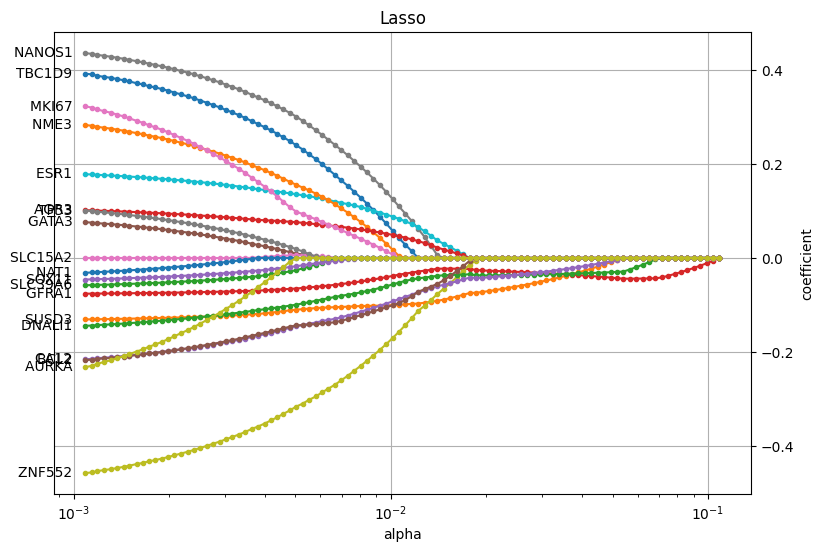

In [31]:
cox_Lasso = CoxnetSurvivalAnalysis(l1_ratio=1.0, alpha_min_ratio=0.01)
cox_Lasso.fit(X_train, Y_train)
coefficient_lasso = pd.DataFrame(cox_Lasso.coef_, index=X.columns, columns=np.round(cox_Lasso.alphas_, 5))
plot_coefficients(coefficient_lasso, len(X_train), title="Lasso")

<font size="4">Elastic Net</font>

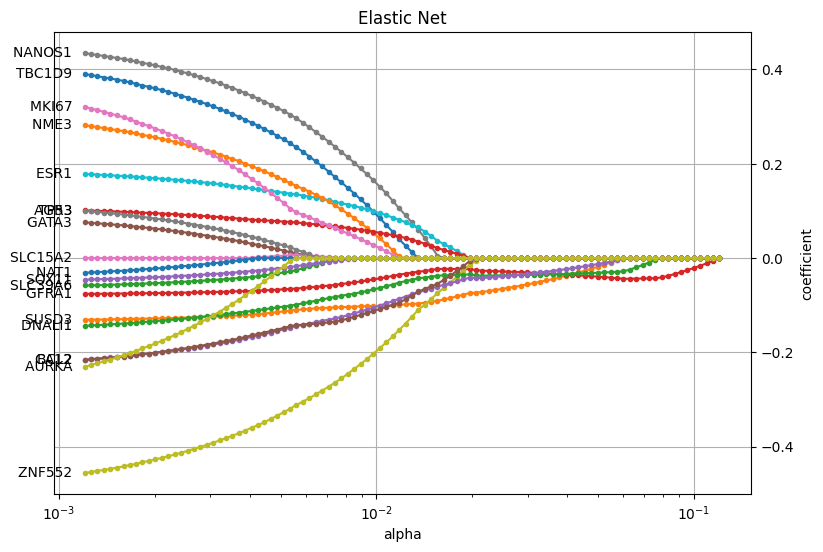

In [32]:
cox_elastic_net = CoxnetSurvivalAnalysis(l1_ratio=0.9, alpha_min_ratio=0.01)
cox_elastic_net.fit(X_train, Y_train)
coffiencients_elastic_net = pd.DataFrame(
    cox_elastic_net.coef_, index=X.columns, columns=np.round(cox_elastic_net.alphas_, 5)
)

plot_coefficients(coffiencients_elastic_net, n_highlight=len(X_train), title="Elastic Net")


<font size="4">Cox Ridge</font>

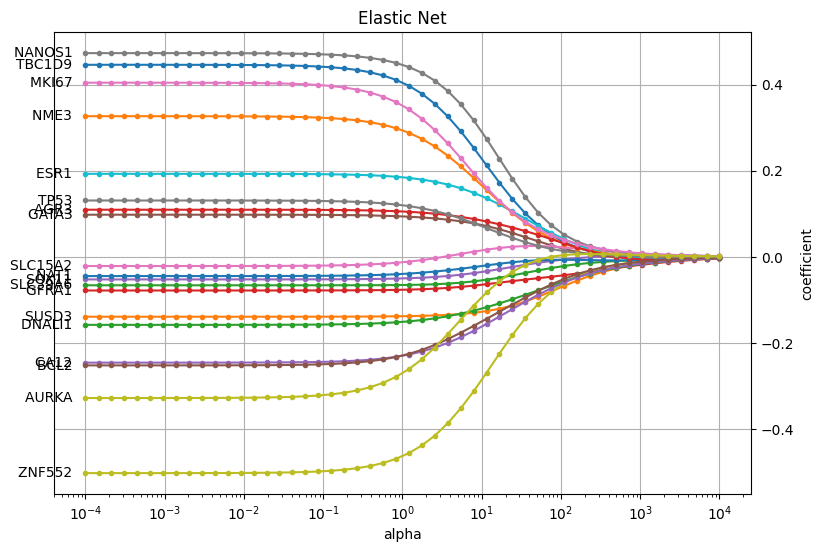

In [30]:
betas_ridge, chp_predict_ridge, chp_survival_curve_ridge, chp_risk_curve_ridge = Cox_l2_regression(
    X_train, Y_train, X_test, draw_plot=False, title="Ridge"
)

plot_coefficients(betas_ridge, n_highlight=len(X_train), title="Elastic Net")

In [36]:
import warnings
from sklearn.exceptions import FitFailedWarning
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
coxnet_pipe = make_pipeline(StandardScaler(), CoxnetSurvivalAnalysis(l1_ratio=0.9, alpha_min_ratio=0.01, max_iter=100))
warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", FitFailedWarning)

coxnet_pipe.fit(X_log, Y)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('coxnetsurvivalanalysis',
                 CoxnetSurvivalAnalysis(alpha_min_ratio=0.01, l1_ratio=0.9,
                                        max_iter=100))])

In [37]:
estimated_alphas = coxnet_pipe.named_steps["coxnetsurvivalanalysis"].alphas_
cv = KFold(n_splits=5, shuffle=True, random_state=42)
gcv = GridSearchCV(
    make_pipeline(StandardScaler(), CoxnetSurvivalAnalysis(l1_ratio=0.9)),
    param_grid={"coxnetsurvivalanalysis__alphas": [[v] for v in map(float, estimated_alphas)]},
    cv=cv,
    error_score=0.5,
    n_jobs=1
).fit(X, Y)

In [38]:
cv_results = pd.DataFrame(gcv.cv_results_)

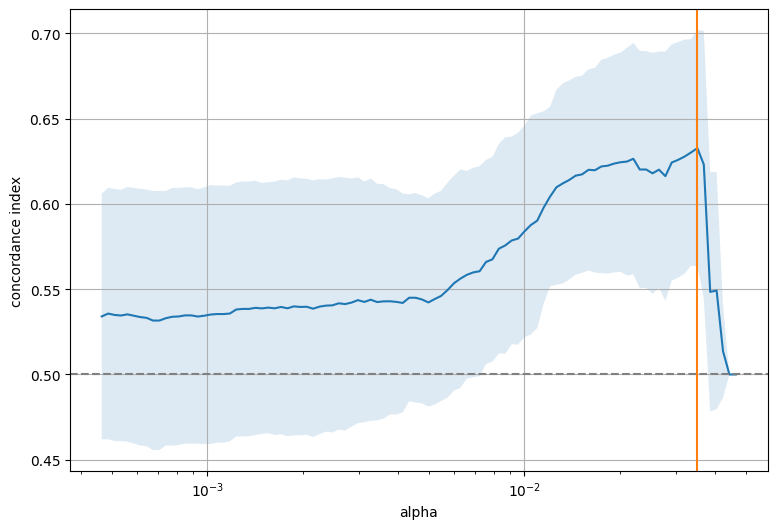

In [39]:
alphas = cv_results.param_coxnetsurvivalanalysis__alphas.map(lambda x: x[0])
mean = cv_results.mean_test_score
std = cv_results.std_test_score

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(alphas, mean)
ax.fill_between(alphas, mean - std, mean + std, alpha=0.15)
ax.set_xscale("log")
ax.set_ylabel("concordance index")
ax.set_xlabel("alpha")
ax.axvline(gcv.best_params_["coxnetsurvivalanalysis__alphas"][0], c="C1")
ax.axhline(0.5, color="grey", linestyle="--")
ax.grid(True)

Number of non-zero coefficients: 2


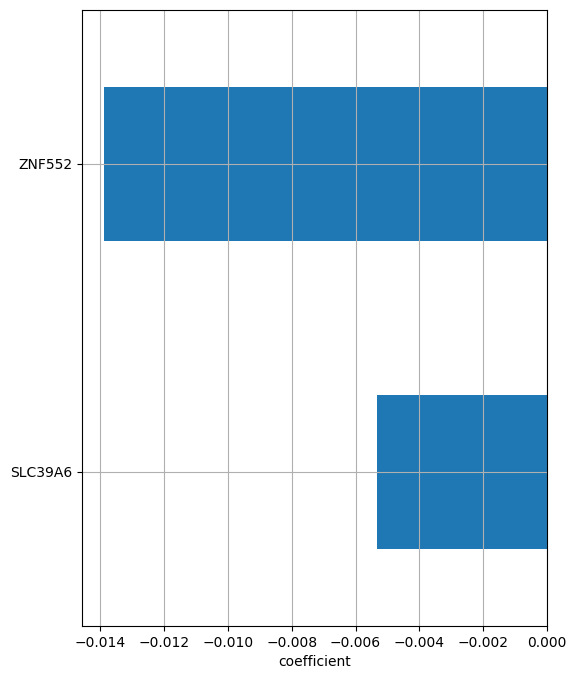

In [44]:
best_model = gcv.best_estimator_.named_steps["coxnetsurvivalanalysis"]
best_coefs = pd.DataFrame(best_model.coef_, index=X.columns, columns=["coefficient"])

non_zero = np.sum(best_coefs.iloc[:, 0] != 0)
print(f"Number of non-zero coefficients: {non_zero}")

non_zero_coefs = best_coefs.query("coefficient != 0")
coef_order = non_zero_coefs.abs().sort_values("coefficient").index

_, ax = plt.subplots(figsize=(6, 8))
non_zero_coefs.loc[coef_order].plot.barh(ax=ax, legend=False)
ax.set_xlabel("coefficient")
ax.grid(True)